NAME: AYUSH PATHAK
ROLL: 60
PRN: 12412918
ASS8
CLASS: CSAI-D-B3


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [19]:
data = pd.DataFrame({
    'Age': [22, 25, 47, 52, 46, 56, 23, 40, 60, 48,
            33, 36, 29, 41, 50, 55, 27, 31, 38, 44,
            23, 26, 49, 53, 45, 57, 28, 42, 61, 39],

    'Gender': ['F','M','F','F','M','M','F','F','M','M',
               'F','M','F','M','F','M','F','M','F','M',
               'F','M','F','F','M','M','F','M','F','M'],

    'Income': [20000, 35000, 50000, 65000, 48000, 70000,
               22000, 45000, 80000, 52000,
               30000, 40000, 27000, 47000, 60000, 72000,
               29000, 31000, 43000, 51000,
               21000, 36000, 52000, 64000, 49000, 71000,
               28000, 46000, 82000, 44000],

    'Purchase_Frequency': [2,3,5,6,4,7,1,4,8,5,
                           3,4,2,5,6,7,2,3,4,5,
                           2,3,5,6,4,7,3,4,8,4],

    'Response': ['No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','No',
                 'No','Yes','No','Yes','Yes','Yes','No','No','Yes','Yes',
                 'No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','No']
})

data.head()

,Age,Gender,Income,Purchase_Frequency,Response
0,22,F,20000,2,No
1,25,M,35000,3,Yes
2,47,F,50000,5,Yes
3,52,F,65000,6,Yes
4,46,M,48000,4,No


In [20]:
le_gender = LabelEncoder()
le_response = LabelEncoder()

data['Gender'] = le_gender.fit_transform(data['Gender'])
data['Response'] = le_response.fit_transform(data['Response'])

X = data.drop('Response', axis=1)
y = data['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:\n", cm)
    print("Accuracy  :", round(accuracy, 3))
    print("Precision :", round(precision, 3))
    print("Recall    :", round(recall, 3))
    print("F1 Score  :", round(f1, 3))

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy, precision, recall, f1


===== Logistic Regression =====
Confusion Matrix:
 [[2 2]
 [0 5]]
Accuracy  : 0.778
Precision : 0.714
Recall    : 1.0
F1 Score  : 0.833


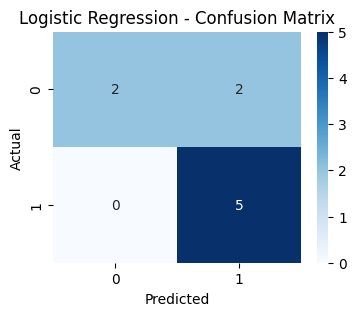

In [22]:
lr = LogisticRegression()
lr_results = evaluate_model(lr, "Logistic Regression")


===== Decision Tree =====
Confusion Matrix:
 [[3 1]
 [1 4]]
Accuracy  : 0.778
Precision : 0.8
Recall    : 0.8
F1 Score  : 0.8


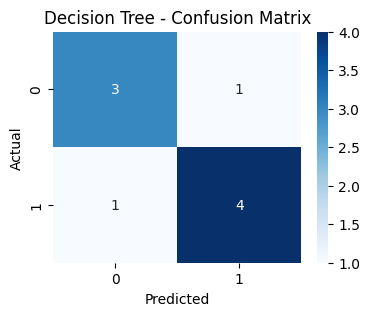

In [23]:
dt = DecisionTreeClassifier(random_state=42)
dt_results = evaluate_model(dt, "Decision Tree")


===== Random Forest =====
Confusion Matrix:
 [[3 1]
 [0 5]]
Accuracy  : 0.889
Precision : 0.833
Recall    : 1.0
F1 Score  : 0.909


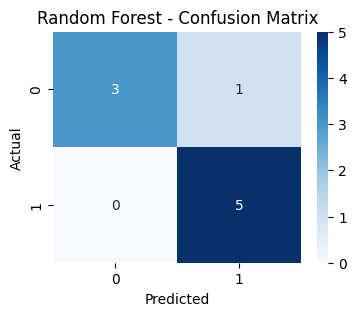

In [24]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_results = evaluate_model(rf, "Random Forest")

In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_results[0], dt_results[0], rf_results[0]],
    "Precision": [lr_results[1], dt_results[1], rf_results[1]],
    "Recall": [lr_results[2], dt_results[2], rf_results[2]],
    "F1 Score": [lr_results[3], dt_results[3], rf_results[3]]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.777778,0.714286,1.0,0.833333
1,Decision Tree,0.777778,0.800000,0.8,0.800000
2,Random Forest,0.888889,0.833333,1.0,0.909091
